# Matrix Factorization на PyTorch с BPR loss

Альтернативный генератор кандидатов для Stage 1.

**Отличие от SVD:**
- SVD оптимизирует MSE по известным рейтингам (explicit feedback)
- BPR оптимизирует попарное ранжирование: просмотренное > непросмотренного

**Архитектура:**
```
user_id -> Embedding(n_factors) +
                                | -> dot product -> BPR loss
item_id -> Embedding(n_factors) +
```

In [27]:
import sys
sys.path.append('../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
from sklearn.decomposition import PCA

from mf_model import MFRecommender
from metrics import recall_at_k, evaluate_all, ndcg_at_k, coverage

from candidates import SVDRecommender

sns.set_theme(style='whitegrid', palette='muted')
DATA_DIR   = Path('../data')
MODELS_DIR = Path('../models')

print(f'PyTorch: {torch.__version__}')
print(f'Device:  {"cuda" if torch.cuda.is_available() else "cpu"}')

PyTorch: 2.13.0+cu126
Device:  cpu


In [3]:
train_df = pd.read_parquet(DATA_DIR / 'train.parquet')
val_df   = pd.read_parquet(DATA_DIR / 'val.parquet')

ground_truth = val_df[['user_id', 'movie_id']].copy()
train_users  = train_df['user_id'].unique()
ground_truth = ground_truth[ground_truth['user_id'].isin(train_users)]
eval_users   = ground_truth['user_id'].unique().tolist()

print(f'Train: {len(train_df):,}')
print(f'Eval users: {len(eval_users):,}')

Train: 976,049
Eval users: 6,040


## 1. Обучение MF с BPR loss

In [4]:
mf = MFRecommender(
    n_factors=32,
    n_epochs=20,
    batch_size=1024,
    lr=1e-3,
    weight_decay=1e-5,
    top_k=100,
)

mf.fit(train_df)

Epoch 5/20 - Loss: 0.2997
Epoch 10/20 - Loss: 0.2549
Epoch 15/20 - Loss: 0.2382
Epoch 20/20 - Loss: 0.2303


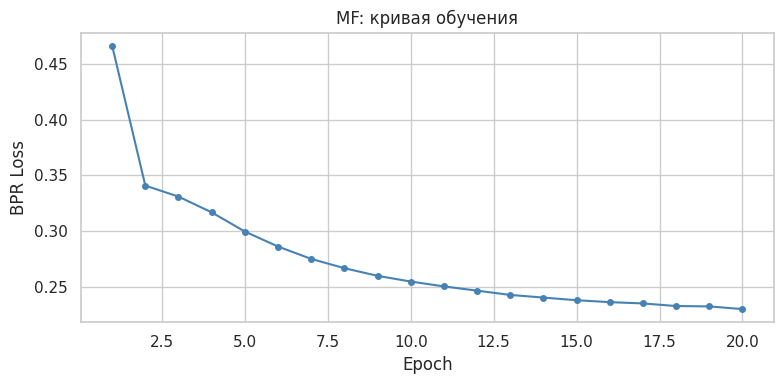

In [5]:
# Кривая обучения
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(mf._losses) + 1), mf._losses, marker='o', color='steelblue', markersize=4)
plt.xlabel('Epoch')
plt.ylabel('BPR Loss')
plt.title('MF: кривая обучения')
plt.tight_layout()
plt.savefig(DATA_DIR / 'mf_loss_curve.png', bbox_inches='tight')
plt.show()

## 2. Подбор n_factors

In [7]:
factors_to_try = [16, 32, 64]
results_mf = []

for n in factors_to_try:
    m = MFRecommender(n_factors=n, n_epochs=15, top_k=100)
    m.fit(train_df)
    recs = m.recommend(eval_users, top_k=100)
    recall_val = recall_at_k(recs, ground_truth, k=100)
    results_mf.append({'n_factors': n, 'recall': recall_val, 'model': m, 'recs': recs})
    print(f'n_factors={n:3d} -> Recall@100={recall_val:.4f}')

best_mf = max(results_mf, key=lambda x: x['recall'])
print(f'\nЛучший результат: n_factors={best_mf["n_factors"]} -> Recall@100={best_mf["recall"]:.4f}')

mf      = best_mf['model']
recs_mf = best_mf['recs']

mf.save(MODELS_DIR / 'mf.pkl')

Epoch 5/15 - Loss: 0.3293
Epoch 10/15 - Loss: 0.2815
Epoch 15/15 - Loss: 0.2576
n_factors= 16 -> Recall@100=0.2790
Epoch 5/15 - Loss: 0.2997
Epoch 10/15 - Loss: 0.2549
Epoch 15/15 - Loss: 0.2382
n_factors= 32 -> Recall@100=0.3046
Epoch 5/15 - Loss: 0.2727
Epoch 10/15 - Loss: 0.2396
Epoch 15/15 - Loss: 0.2287
n_factors= 64 -> Recall@100=0.3184

Лучший результат: n_factors=64 -> Recall@100=0.3184


## 3. Сравнение с SVD

In [28]:
svd = SVDRecommender.load(MODELS_DIR / 'svd.pkl')
recs_svd = svd.recommend(eval_users, top_k=100)
movies = pd.read_parquet(DATA_DIR / 'movies.parquet')
all_items = movies['movie_id'].values

comparison = pd.DataFrame({
    'Model':      ['SVD', 'MF (BPR)'],
    'Recall@10':  [recall_at_k(recs_svd, ground_truth, 10),
                   recall_at_k(recs_mf,  ground_truth, 10)],
    'Recall@50':  [recall_at_k(recs_svd, ground_truth, 50),
                   recall_at_k(recs_mf,  ground_truth, 50)],
    'Recall@100': [recall_at_k(recs_svd, ground_truth, 100),
                   recall_at_k(recs_mf,  ground_truth, 100)],
    'NDCG@10':    [ndcg_at_k(recs_svd, ground_truth, 10),
                   ndcg_at_k(recs_mf,  ground_truth, 10)],
    'Coverage@100': [coverage(recs_svd, all_items, k=100),
                     coverage(recs_mf,  all_items, k=100)],
})

print(comparison.set_index('Model').to_string())

          Recall@10  Recall@50  Recall@100   NDCG@10  Coverage@100
Model                                                             
SVD        0.054470   0.156291    0.223786  0.039226      0.504249
MF (BPR)   0.059437   0.199890    0.318377  0.043216      0.501674


## 4. Анализ эмбеддингов

Эмбеддинги фильмов можно визуализировать через PCA -
похожие фильмы должны кластеризоваться вместе.

Объяснённая дисперсия PCA: 0.602
genres
Drama          1603
Comedy         1200
Action          503
Thriller        492
Romance         471
Horror          343
Adventure       283
Sci-Fi          276
Children's      251
Crime           211
War             143
Documentary     127
Musical         114
Mystery         106
Animation       105
Fantasy          68
Western          68
Film-Noir        44
Name: count, dtype: int64

Топ жанры: ['Drama', 'Comedy', 'Action', 'Thriller', 'Romance', 'Horror']


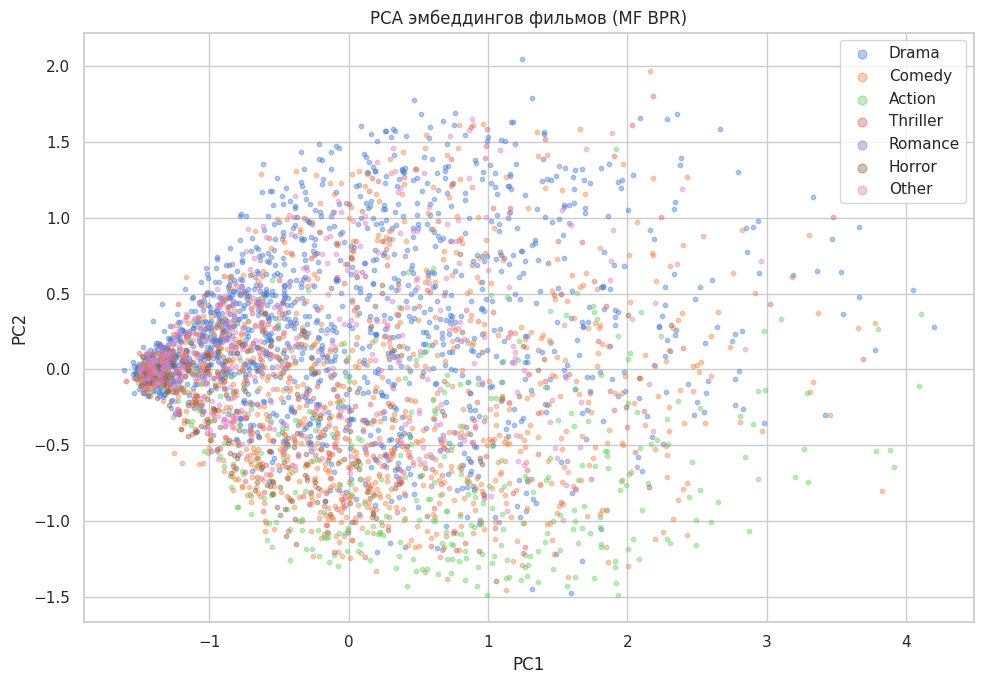

In [9]:
movies = pd.read_parquet(DATA_DIR / 'movies.parquet')
user_embs, item_embs = mf.get_embeddings()

# PCA до 2D для визуализации
pca = PCA(n_components=2, random_state=42)
item_embs_2d = pca.fit_transform(item_embs)
print(f'Объяснённая дисперсия PCA: {pca.explained_variance_ratio_.sum():.3f}')

# Берём топ-жанры для раскраски
genre_counts = (
    movies['genres']
    .str.split('|')
    .explode()
    .value_counts()
)
print(genre_counts)

top_genres = genre_counts.head(6).index.tolist()
print(f'\nТоп жанры: {top_genres}')

movies['primary_genre'] = movies['genres'].apply(
    lambda g: next((x for x in top_genres if x in g), 'Other')
)

# Только фильмы из train
train_items = pd.DataFrame({'movie_id': mf._item_ids})
plot_df = train_items.merge(movies[['movie_id', 'primary_genre']], on='movie_id')
plot_df['x'] = item_embs_2d[:len(plot_df), 0]
plot_df['y'] = item_embs_2d[:len(plot_df), 1]

plt.figure(figsize=(10, 7))
for genre in top_genres + ['Other']:
    subset = plot_df[plot_df['primary_genre'] == genre]
    plt.scatter(subset['x'], subset['y'], label=genre, alpha=0.4, s=10)
plt.legend(markerscale=2)
plt.title('PCA эмбеддингов фильмов (MF BPR)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig(DATA_DIR / 'mf_embeddings_pca.png', bbox_inches='tight')
plt.show()

## 5. Stage 2: Ранжирование кандидатов MF через CatBoostRanker

In [18]:
import importlib
import features as features_module
importlib.reload(features_module)
from features import build_user_features, build_item_features, build_interaction_features

movies = pd.read_parquet(DATA_DIR / 'movies.parquet')

# Формируем кандидаты от MF с метками
gt_set = set(zip(val_df['user_id'], val_df['movie_id']))

candidates_mf = recs_mf.copy()
candidates_mf.columns = ['user_id', 'movie_id', 'candidate_score', 'candidate_rank']
candidates_mf['in_popularity_top'] = 0
candidates_mf['label'] = candidates_mf.apply(
    lambda row: int((row['user_id'], row['movie_id']) in gt_set), axis=1
)

print(f'Кандидатов:    {len(candidates_mf):,}')
print(f'Позитивов:     {candidates_mf["label"].sum():,}')
print(f'Positive rate: {candidates_mf["label"].mean():.4f}')

Кандидатов:    604,000
Позитивов:     5,769
Positive rate: 0.0096


In [19]:
user_features = build_user_features(train_df)
item_features = build_item_features(train_df, movies)
dataset_mf    = build_interaction_features(candidates_mf, user_features, item_features, train_df)

print(f'Датасет для ранкера: {dataset_mf.shape}')

Датасет для ранкера: (604000, 21)


In [20]:
users_with_positives = dataset_mf[dataset_mf['label'] == 1]['user_id'].unique()
dataset_filtered = dataset_mf[dataset_mf['user_id'].isin(users_with_positives)]

np.random.seed(42)
train_users_rank = np.random.choice(
    users_with_positives,
    size=int(len(users_with_positives) * 0.8),
    replace=False
)
val_users_rank = np.setdiff1d(users_with_positives, train_users_rank)

train_rank_mf = dataset_filtered[dataset_filtered['user_id'].isin(train_users_rank)].sort_values('user_id')
val_rank_mf   = dataset_filtered[dataset_filtered['user_id'].isin(val_users_rank)].sort_values('user_id')

print(f'Train: {len(train_rank_mf):,} записей, {len(train_users_rank):,} пользователей')
print(f'Val:   {len(val_rank_mf):,} записей, {len(val_users_rank):,} пользователей')

Train: 295,800 записей, 2,958 пользователей
Val:   74,000 записей, 740 пользователей


In [22]:
from ranker import TwoStageRanker
ranker_mf = TwoStageRanker(
    iterations=500,
    learning_rate=0.05,
    depth=6,
)

ranker_mf.fit(train_rank_mf, val_df=val_rank_mf)
ranker_mf.save(MODELS_DIR / 'ranker_mf.pkl')

0:	test: 0.1370035	best: 0.1370035 (0)	total: 128ms	remaining: 1m 4s
100:	test: 0.2061071	best: 0.2064931 (60)	total: 6.57s	remaining: 25.9s
200:	test: 0.2094776	best: 0.2096824 (191)	total: 12.8s	remaining: 19s
300:	test: 0.2032474	best: 0.2096824 (191)	total: 18.9s	remaining: 12.5s
400:	test: 0.2013037	best: 0.2096824 (191)	total: 25.4s	remaining: 6.28s
499:	test: 0.1996532	best: 0.2096824 (191)	total: 32.1s	remaining: 0us

bestTest = 0.2096824091
bestIteration = 191

Shrink model to first 192 iterations.


In [24]:
ground_truth_eval = val_df[['user_id', 'movie_id']].copy()

# MF + CatBoost
recs_mf_ranked = ranker_mf.recommend(dataset_mf, top_k=10)

# MF без ранкера
recs_mf_top10 = (
    candidates_mf.sort_values(['user_id', 'candidate_score'], ascending=[True, False])
    .groupby('user_id')
    .head(10)
    .assign(rank=lambda df: df.groupby('user_id')['candidate_score']
            .rank(ascending=False, method='first').astype(int))
    [['user_id', 'movie_id', 'rank']]
)

# SVD + CatBoost
ranker_svd = TwoStageRanker.load(MODELS_DIR / 'ranker.pkl')
candidates_svd = pd.read_parquet(DATA_DIR / 'candidates_for_ranking.parquet')
dataset_svd = build_interaction_features(candidates_svd, user_features, item_features, train_df)
recs_svd_ranked = ranker_svd.recommend(dataset_svd, top_k=10)

print('MF + CatBoost:')
print(evaluate_all(recs_mf_ranked, ground_truth_eval, k_values=[5, 10]))

print('\nMF only (top-10):')
print(evaluate_all(recs_mf_top10, ground_truth_eval, k_values=[5, 10]))

print('\nSVD + CatBoost (из ноутбука 03):')
print(evaluate_all(recs_svd_ranked, ground_truth_eval, k_values=[5, 10]))

MF + CatBoost:
               @5     @10
Precision  0.0382  0.0291
Recall     0.0637  0.0970
NDCG       0.0601  0.0752
HitRate    0.1709  0.2452
MRR        0.1011  0.1108

MF only (top-10):
               @5     @10
Precision  0.0218  0.0178
Recall     0.0363  0.0594
NDCG       0.0328  0.0432
HitRate    0.0992  0.1551
MRR        0.0540  0.0614

SVD + CatBoost (из ноутбука 03):
               @5     @10
Precision  0.0336  0.0248
Recall     0.0560  0.0826
NDCG       0.0533  0.0653
HitRate    0.1472  0.2071
MRR        0.0890  0.0969


MF с BPR loss превзошёл SVD как генератор кандидатов по финальным метрикам: 

HitRate@10 вырос с 0.207 до 0.245, NDCG@10 с 0.065 до 0.075. 

Добавление CatBoostRanker на обоих наборах кандидатов дало существенный прирост относительно Stage 1 без ранжирования: для MF HitRate@10 вырос с 0.155 до 0.245, что подтверждает ценность двустадийной архитектуры. Итоговая система MF + CatBoost выбрана как основная.

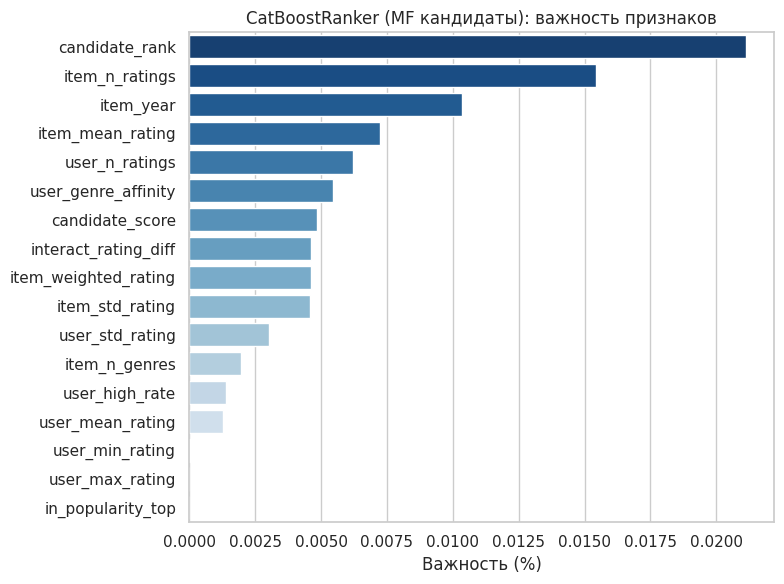

In [25]:
fi_mf = ranker_mf.get_feature_importance(train_rank_mf)

plt.figure(figsize=(8, 6))
sns.barplot(data=fi_mf, x='importance', y='feature', palette='Blues_r')
plt.xlabel('Важность (%)')
plt.ylabel('')
plt.title('CatBoostRanker (MF кандидаты): важность признаков')
plt.tight_layout()
plt.show()